# 📈 Modeling on Sample Data (1 Million Rows)

"""
Purpose:
This notebook aims to build and evaluate baseline models on the sampled dataset (1 million rows) from the UK Real Estate data.
The goal is to assess the predictive power of engineered features before moving to the full dataset.

Key Objectives:
1. Train and evaluate baseline regression models.
2. Compare model performance metrics (MAE, RMSE, R²).
3. Identify key features using feature importance.

Expected Output:
- Trained models with performance comparison.
- Feature importance analysis.
- Insights for further improvements.

Author: Your Name
Date: April 2025
"""

In [ ]:
from google.colab import auth
auth.authenticate_user()

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from datetime import datetime
from google.cloud import storage
import os

from google.cloud import storage
import pandas as pd

# GCS download function
def download_sample():
    bucket_name = "boothill2001-dataset"
    gcs_path = "uk_property_data/processed/sample_real_estate.csv"
    local_path = "data/processed/sample_real_estate.csv"

    # Create the directory if it doesn't exist
    os.makedirs(os.path.dirname(local_path), exist_ok=True)

    try:
        client = storage.Client()
        bucket = client.bucket(bucket_name)

        print("Downloading the sampled data from GCS...")
        blob = bucket.blob(gcs_path)
        blob.download_to_filename(local_path)
        print(f"Sampled data downloaded successfully to {local_path}!")
    except Exception as e:
        print(f"Error downloading file: {e}")

# Load the sampled data
download_sample()
df = pd.read_csv("data/processed/sample_real_estate.csv")
print("Sampled data loaded successfully! Shape:", df.shape)


# One-hot encoding for categorical variables
df = pd.get_dummies(df, columns=['Property_Type', 'Urban_Rural', 'Season'], drop_first=True)

# Update the feature list after encoding
encoded_features = [col for col in df.columns if col.startswith('Property_Type_') or
                    col.startswith('Season_') or col.startswith('Urban_Rural_')]

# Final feature list
features = ['Is_Weekend', 'High_Value_Property', 'Holiday_Season', 'Price_Change_Ratio'] + encoded_features
target = 'Log_Price'

# Train-test split
X = df[features]
y = df[target]

# Display the feature names to verify
print("Final feature list:", features)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Baseline Model: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions and evaluation
y_pred_lr = lr.predict(X_test)
print("Linear Regression - MAE:", mean_absolute_error(y_test, y_pred_lr))
print("Linear Regression - RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("Linear Regression - R²:", r2_score(y_test, y_pred_lr))

# Model: Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest - MAE:", mean_absolute_error(y_test, y_pred_rf))
print("Random Forest - RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("Random Forest - R²:", r2_score(y_test, y_pred_rf))

# Model: XGBoost
xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print("XGBoost - MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("XGBoost - RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("XGBoost - R²:", r2_score(y_test, y_pred_xgb))


Sampled data downloaded successfully to data/processed/sample_real_estate.csv!
Sampled data loaded successfully! Shape: (1000000, 27)
Final feature list: ['Is_Weekend', 'High_Value_Property', 'Holiday_Season', 'Price_Change_Ratio', 'Property_Type_F', 'Property_Type_O', 'Property_Type_S', 'Property_Type_T', 'Season_Spring', 'Season_Summer', 'Season_Winter']
Linear Regression - MAE: 0.4514183030131219
Linear Regression - RMSE: 0.6194017355248144
Linear Regression - R²: 0.4599839555000661
Random Forest - MAE: 4.823457005689006e-05
Random Forest - RMSE: 0.0027293001438007886
Random Forest - R²: 0.9999895150968356
XGBoost - MAE: 0.010474306318792679
XGBoost - RMSE: 0.08456271839071595
XGBoost - R²: 0.9899348628116311


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 31 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   Transaction_ID       1000000 non-null  object 
 1   Price                1000000 non-null  int64  
 2   Date_of_Transfer     1000000 non-null  object 
 3   Postcode             1000000 non-null  object 
 4   Old/New              1000000 non-null  object 
 5   Duration             1000000 non-null  object 
 6   PAON                 1000000 non-null  object 
 7   Street               1000000 non-null  object 
 8   Locality             642346 non-null   object 
 9   Town/City            1000000 non-null  object 
 10  District             1000000 non-null  object 
 11  County               1000000 non-null  object 
 12  PPDCategory_Type     1000000 non-null  object 
 13  Record_Status        1000000 non-null  object 
 14  Year                 1000000 non-null  int64  
 15 


Cross-Validation for Random Forest
MAE (mean ± std): 0.0001 ± 0.0000
RMSE (mean ± std): 0.0030 ± 0.0003
R² (mean ± std): 1.0000 ± 0.0000


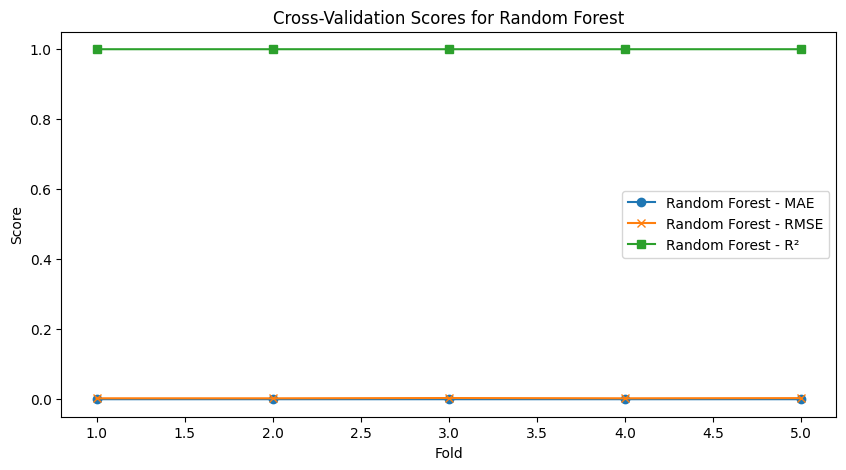


Cross-Validation for XGBoost
MAE (mean ± std): 0.0107 ± 0.0002
RMSE (mean ± std): 0.0864 ± 0.0027
R² (mean ± std): 0.9895 ± 0.0006


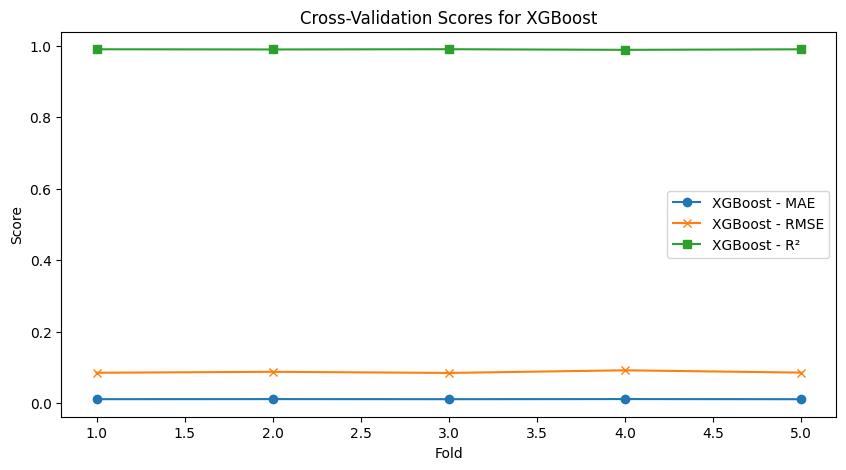

In [ ]:
from sklearn.model_selection import cross_val_score, KFold

# K-Fold Cross Validation (k=5)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cross_validate_model(model, X, y, model_name):
    print(f"\nCross-Validation for {model_name}")
    cv_mae = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_absolute_error')
    cv_rmse = cross_val_score(model, X, y, cv=kf, scoring='neg_root_mean_squared_error')
    cv_r2 = cross_val_score(model, X, y, cv=kf, scoring='r2')

    print(f"MAE (mean ± std): {abs(cv_mae.mean()):.4f} ± {cv_mae.std():.4f}")
    print(f"RMSE (mean ± std): {abs(cv_rmse.mean()):.4f} ± {cv_rmse.std():.4f}")
    print(f"R² (mean ± std): {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

    # Plotting Cross-Validation Scores
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, 6), abs(cv_mae), marker='o', label=f'{model_name} - MAE')
    plt.plot(range(1, 6), abs(cv_rmse), marker='x', label=f'{model_name} - RMSE')
    plt.plot(range(1, 6), cv_r2, marker='s', label=f'{model_name} - R²')
    plt.title(f'Cross-Validation Scores for {model_name}')
    plt.xlabel('Fold')
    plt.ylabel('Score')
    plt.legend()
    plt.show()

# Cross-Validate Random Forest
cross_validate_model(RandomForestRegressor(random_state=42), X, y, "Random Forest")

# Cross-Validate XGBoost
cross_validate_model(XGBRegressor(random_state=42), X, y, "XGBoost")


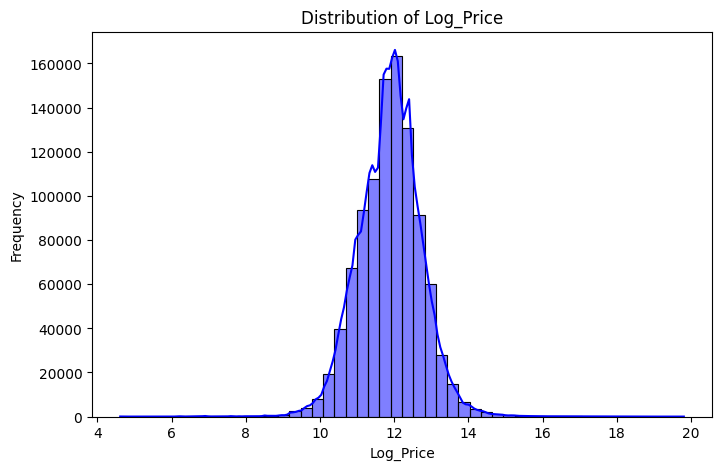

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of Log_Price
plt.figure(figsize=(8, 5))
sns.histplot(y, bins=50, kde=True, color="blue")
plt.title("Distribution of Log_Price")
plt.xlabel("Log_Price")
plt.ylabel("Frequency")
plt.show()


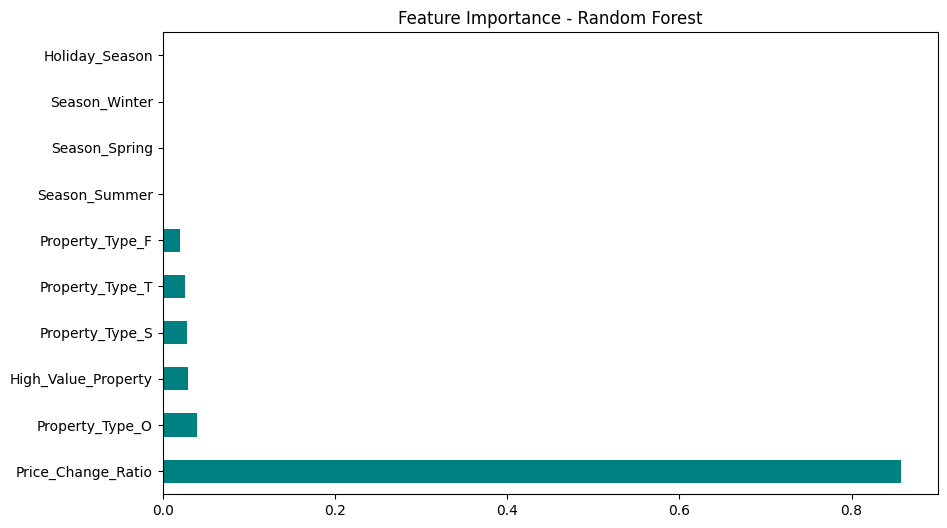

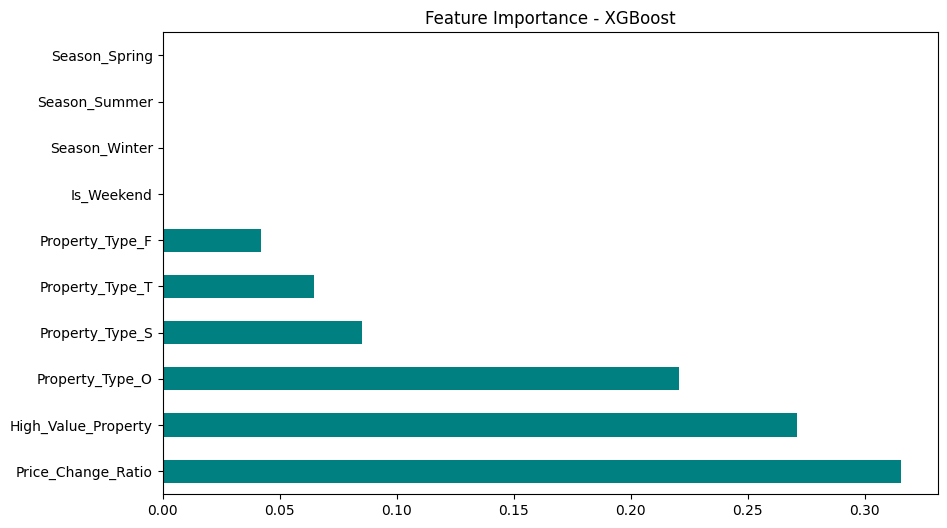

In [ ]:
# Feature Importance Plot
def plot_feature_importance(model, model_name):
    plt.figure(figsize=(10, 6))
    importance = pd.Series(model.feature_importances_, index=X.columns)
    importance.nlargest(10).plot(kind='barh', color='teal')
    plt.title(f'Feature Importance - {model_name}')
    plt.show()

# Plot for Random Forest
plot_feature_importance(rf, "Random Forest")

# Plot for XGBoost
plot_feature_importance(xgb, "XGBoost")


In [ ]:
# Function to evaluate models
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return pd.DataFrame([[name, mae, rmse, r2]], columns=['Model', 'MAE', 'RMSE', 'R²'])

# DataFrame to store results
results = pd.DataFrame()

# Add results for Linear Regression
results = pd.concat([results, evaluate_model("Linear Regression", y_test, y_pred_lr)])

# Add results for Random Forest
results = pd.concat([results, evaluate_model("Random Forest", y_test, y_pred_rf)])

# Add results for XGBoost
results = pd.concat([results, evaluate_model("XGBoost", y_test, y_pred_xgb)])

print("\nModel Performance Comparison:")
print(results)



Model Performance Comparison:
               Model       MAE      RMSE        R²
0  Linear Regression  0.451418  0.619402  0.459984
0      Random Forest  0.000048  0.002729  0.999990
0            XGBoost  0.010474  0.084563  0.989935
